### Testing simple buy and hold strategy


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd

from backtester.strategies.strategies import positions_to_returns

# Made-up asset returns: 5 days of +1% each
asset_returns = pd.Series([0.01, 0.01, 0.01, 0.01, 0.01])

# Strategy: position = 1(full hold) for first 3 days, 0(no hold) for last 2
positions = pd.Series([1, 1, 1, 0, 0])

strategy_returns = positions_to_returns(positions, asset_returns)

print("Asset returns:    ", asset_returns.tolist())
print("Positions:        ", positions.tolist())
print("Strategy returns: ", strategy_returns.tolist())

Asset returns:     [0.01, 0.01, 0.01, 0.01, 0.01]
Positions:         [1, 1, 1, 0, 0]
Strategy returns:  [nan, 0.01, 0.01, 0.01, 0.0]


In [2]:
from backtester.strategies.strategies import buy_and_hold
from backtester.data.loader import load_ticker_with_cache
from backtester.metrics.metrics import daily_returns, performance_report


df = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
prices = df["Close"]
asset_returns = daily_returns(prices)

#defining the strategy
positions = buy_and_hold(prices)

strategy_returns = positions_to_returns(positions, asset_returns)

report = performance_report(strategy_returns)

print("Buy & Hold Reliance — Performance Report")
print("=" * 42)
for metric, value in report.items():
    print(f"  {metric:<25} {value:>8.4f}")

#output wil be identical to previous report 


Loading RELIANCE.NS from cache
Buy & Hold Reliance — Performance Report
  total_return                0.7856
  annualized_return           0.1255
  annualized_volatility       0.2974
  sharpe_ratio                0.2201
  max_drawdown               -0.4408


### Testing Moving Average CrossOver Strategy

In [3]:
from backtester.strategies.strategies import moving_average_crossover

df = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
prices = df["Close"]

positions = moving_average_crossover(prices, short_window=50, long_window=200)

print(f"Number of days: {len(positions)}")
print(f"Days in position (invested): {(positions == 1).sum()}")
print(f"Days in cash:                 {(positions == 0).sum()}")
print(f"Days NaN (not enough history):{positions.isna().sum()}")

Loading RELIANCE.NS from cache
Number of days: 1237
Days in position (invested): 812
Days in cash:                 226
Days NaN (not enough history):199


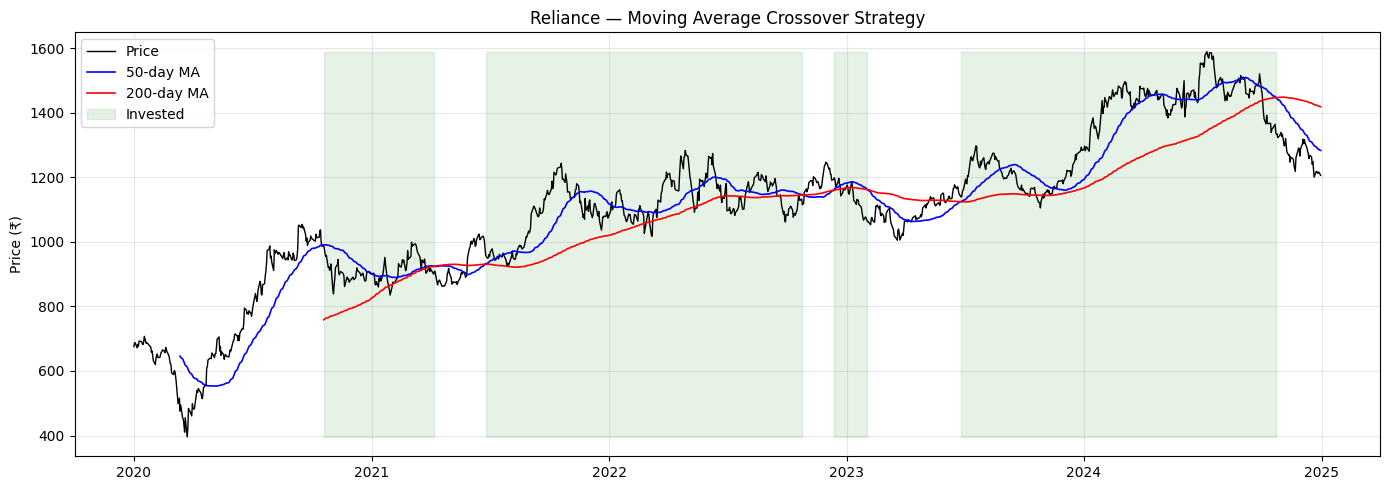

In [4]:
#visualizing the strategy
import matplotlib.pyplot as plt

short_ma = prices.rolling(window=50).mean()
long_ma = prices.rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prices.index, prices.values, label="Price", color="black", linewidth=1)
ax.plot(short_ma.index, short_ma.values, label="50-day MA", color="blue", linewidth=1.2)
ax.plot(long_ma.index, long_ma.values, label="200-day MA", color="red", linewidth=1.2)

# Shade the regions where the strategy is invested
ax.fill_between(prices.index, prices.min(), prices.max(),
                where=(positions == 1), alpha=0.1, color="green", label="Invested")

ax.set_title("Reliance — Moving Average Crossover Strategy")
ax.set_ylabel("Price (₹)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
from backtester.strategies.strategies import positions_to_returns
from backtester.metrics.metrics import daily_returns, performance_report

asset_returns = daily_returns(prices)

# Run the strategy
strategy_returns = positions_to_returns(positions, asset_returns)

# Also compute buy-and-hold for comparison
bh_positions = buy_and_hold(prices)
bh_returns = positions_to_returns(bh_positions, asset_returns)

# Reports
strategy_report = performance_report(strategy_returns)
bh_report = performance_report(bh_returns)

print(f"{'Metric':<25} {'MA Crossover':>15} {'Buy & Hold':>15}")
print("-" * 57)
for metric in strategy_report:
    s = strategy_report[metric]
    b = bh_report[metric]
    print(f"{metric:<25} {s:>15.4f} {b:>15.4f}")

Metric                       MA Crossover      Buy & Hold
---------------------------------------------------------
total_return                       0.1218          0.7856
annualized_return                  0.0283          0.1255
annualized_volatility              0.2197          0.2974
sharpe_ratio                      -0.1442          0.2201
max_drawdown                      -0.2460         -0.4408


In [6]:
"""Trying different parameters of (short,long)"""
parameters_to_try = [
    (20, 50),
    (50, 200),
    (100, 300),
    (10, 100),
]

print(f"{'Short':>6} {'Long':>6} {'Return':>10} {'Vol':>8} {'Sharpe':>8} {'MaxDD':>8}")
print("-" * 50)

for short, long in parameters_to_try:
    positions = moving_average_crossover(prices, short_window=short, long_window=long)
    strategy_returns = positions_to_returns(positions, asset_returns)
    report = performance_report(strategy_returns)
    print(f"{short:>6} {long:>6} {report['annualized_return']:>9.2%} "
          f"{report['annualized_volatility']:>7.2%} "
          f"{report['sharpe_ratio']:>8.3f} "
          f"{report['max_drawdown']:>7.2%}")

 Short   Long     Return      Vol   Sharpe    MaxDD
--------------------------------------------------
    20     50     5.39%  18.43%   -0.033 -41.78%
    50    200     2.83%  21.97%   -0.144 -24.60%
   100    300     1.09%  21.99%   -0.223 -28.53%
    10    100     4.42%  20.16%   -0.079 -29.20%


### Multi Stock Momentum strategy